# 🌿 CNN Plant Disease Detection — PyTorch
### Dataset: Plant Pathology 2020 - FGVC7 (Kaggle)
**Classes:** healthy | multiple_diseases | rust | scab  
**Model:** MobileNetV2 Transfer Learning (**PyTorch** — supports Python 3.13 ✅)

## Step 1: Install Dependencies

In [1]:
# Install PyTorch (CPU version — works on Python 3.13)
# Using %pip is recommended in notebooks to ensure the current kernel is updated.
%pip install torch torchvision kaggle pillow matplotlib seaborn scikit-learn pandas numpy joblib tqdm

print('\n✅ Installation commands sent. If you just installed new packages, please RESTART THE KERNEL (Kernel -> Restart in menu) before proceeding to Step 2.')

Note: you may need to restart the kernel to use updated packages.

✅ Installation commands sent. If you just installed new packages, please RESTART THE KERNEL (Kernel -> Restart in menu) before proceeding to Step 2.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Import Libraries

In [2]:
# Fix for WinError 1114 (DLL load failure) common on Windows
import os, sys, zipfile, warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import joblib
import subprocess  # Needed for Step 3
warnings.filterwarnings('ignore')

try:
    # PyTorch
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    from torchvision import models, transforms
    
    # Weight access (torchvision >= 0.13.0)
    try:
        from torchvision.models import MobileNet_V2_Weights
    except ImportError:
        print('⚠️ MobileNet_V2_Weights not found. Using legacy weights access.')
        MobileNet_V2_Weights = None

    # Sklearn
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import classification_report, confusion_matrix

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f'Python:  {sys.version}')
    print(f'PyTorch: {torch.__version__}')
    print(f'Device:  {DEVICE}')
    print('✅ All imports successful!')
except Exception as e:
    print(f'❌ Error during import: {e}')
    print('👉 Did you run Step 1? If yes, try RESTARTING THE KERNEL (Kernel -> Restart).')
    if 'WinError 1114' in str(e):
        print('💡 DLL Load Error (1114) detected. This is a system-level issue often linked to PyTorch/Anaconda dependencies.')

❌ Error during import: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\mahes\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.
👉 Did you run Step 1? If yes, try RESTARTING THE KERNEL (Kernel -> Restart).
💡 DLL Load Error (1114) detected. This is a system-level issue often linked to PyTorch/Anaconda dependencies.


## Step 3: Download Dataset (Kaggle)

In [3]:
DATASET_DIR = '../dataset/plant-pathology-2020'
os.makedirs(DATASET_DIR, exist_ok=True)

if os.path.exists(os.path.join(DATASET_DIR, 'train.csv')):
    print(f'✅ Dataset already at: {os.path.abspath(DATASET_DIR)}')
else:
    print('📥 Downloading via Kaggle CLI...')
    os.environ['KAGGLE_CONFIG_DIR'] = os.path.expanduser('~/.kaggle')
    result = subprocess.run(
        ['kaggle', 'competitions', 'download',
         '-c', 'plant-pathology-2020-fgvc7', '-p', DATASET_DIR],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print('Error:', result.stderr)

    # Extract all zips
    for f in os.listdir(DATASET_DIR):
        if f.endswith('.zip'):
            print(f'📦 Extracting {f}...')
            with zipfile.ZipFile(os.path.join(DATASET_DIR, f), 'r') as z:
                z.extractall(DATASET_DIR)

print('\nDataset contents:')
for f in sorted(os.listdir(DATASET_DIR)):
    print(f'  {f}')

📥 Downloading via Kaggle CLI...


📦 Extracting plant-pathology-2020-fgvc7.zip...

Dataset contents:
  images
  plant-pathology-2020-fgvc7.zip
  sample_submission.csv
  test.csv
  train.csv


## Step 4: Load & Explore Data

In [4]:
CLASS_NAMES = ['healthy', 'multiple_diseases', 'rust', 'scab']
label2idx   = {c: i for i, c in enumerate(CLASS_NAMES)}
idx2label   = {i: c for c, i in label2idx.items()}

train_df = pd.read_csv(os.path.join(DATASET_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATASET_DIR, 'test.csv'))

# One-hot → label
train_df['label'] = train_df[CLASS_NAMES].idxmax(axis=1)
train_df['label_idx'] = train_df['label'].map(label2idx)

# Find images folder
for subdir in ['images', 'train_images', '']:
    candidate = os.path.join(DATASET_DIR, subdir)
    if os.path.isdir(candidate) and any(f.endswith('.jpg') for f in os.listdir(candidate)):
        IMAGES_DIR = candidate
        break
else:
    IMAGES_DIR = DATASET_DIR

print(f'Images dir: {IMAGES_DIR}')

def get_path(img_id):
    for ext in ['.jpg', '.JPG', '.jpeg']:
        p = os.path.join(IMAGES_DIR, f'{img_id}{ext}')
        if os.path.exists(p): return p
    return os.path.join(IMAGES_DIR, f'{img_id}.jpg')

train_df['image_path'] = train_df['image_id'].apply(get_path)

print(f'Samples: {len(train_df)}')
print(f'\nClass Distribution:')
print(train_df['label'].value_counts())
train_df.head()

Images dir: ../dataset/plant-pathology-2020\images
Samples: 1821

Class Distribution:
label
rust                 622
scab                 592
healthy              516
multiple_diseases     91
Name: count, dtype: int64


,image_id,healthy,multiple_diseases,rust,scab,label,label_idx,image_path
0,Train_0,0,0,0,1,scab,3,../dataset/plant-pathology-2020\images\Train_0...
1,Train_1,0,1,0,0,multiple_diseases,1,../dataset/plant-pathology-2020\images\Train_1...
2,Train_2,1,0,0,0,healthy,0,../dataset/plant-pathology-2020\images\Train_2...
3,Train_3,0,0,1,0,rust,2,../dataset/plant-pathology-2020\images\Train_3...
4,Train_4,1,0,0,0,healthy,0,../dataset/plant-pathology-2020\images\Train_4...


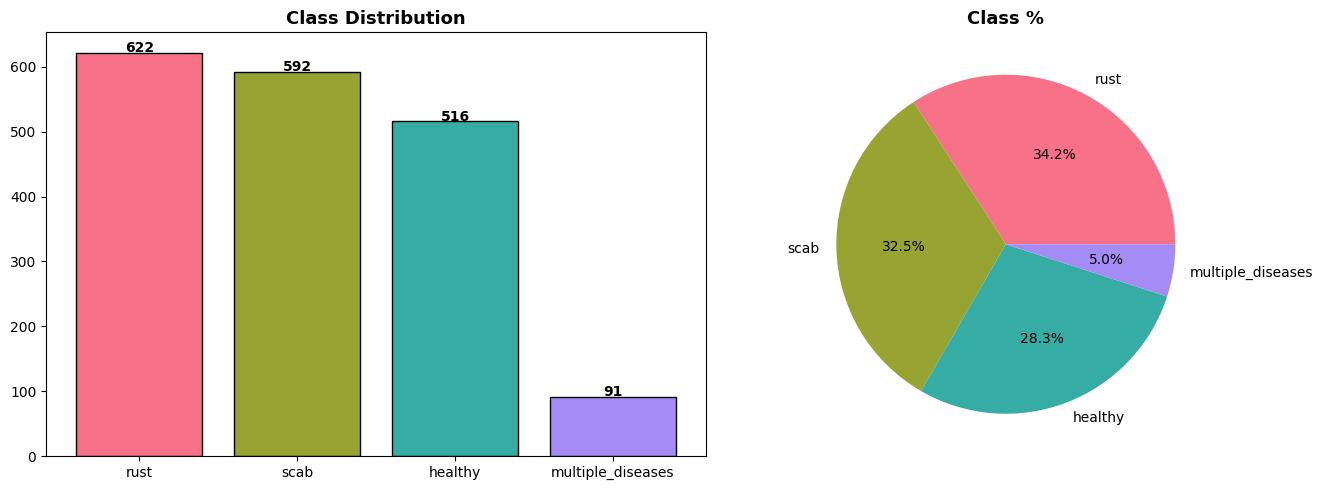

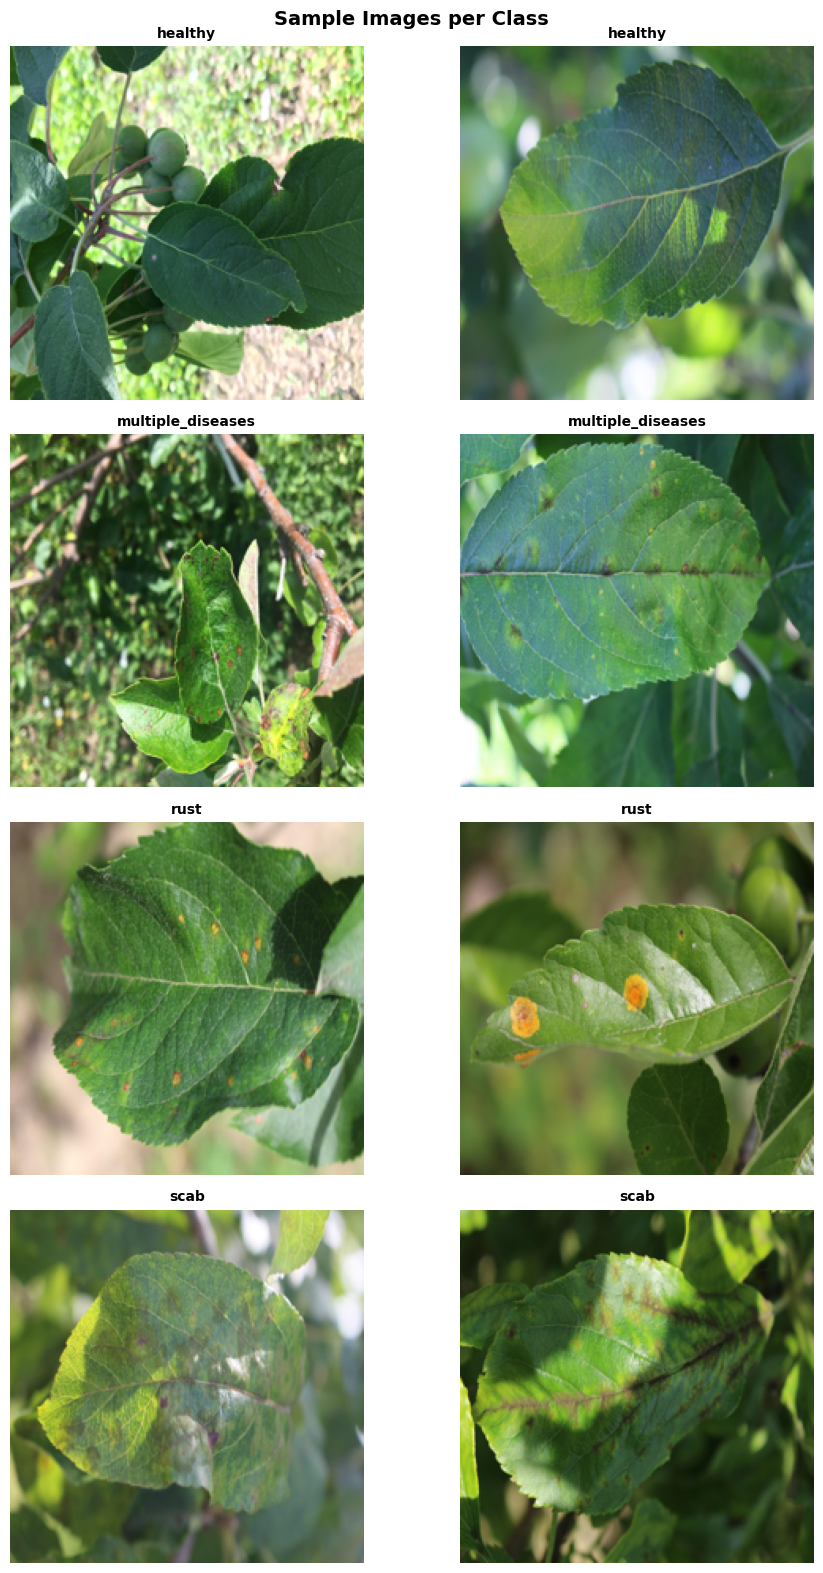

✅ EDA plots saved.


In [5]:
os.makedirs('outputs', exist_ok=True)

counts = train_df['label'].value_counts()
colors = sns.color_palette('husl', 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Class %', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Show sample images
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
for row, cls in enumerate(CLASS_NAMES):
    samples = train_df[train_df['label'] == cls].sample(2, random_state=42)
    for col, (_, r) in enumerate(samples.iterrows()):
        try:
            axes[row][col].imshow(Image.open(r['image_path']).resize((224, 224)))
        except:
            axes[row][col].imshow(Image.new('RGB', (224, 224)))
        axes[row][col].axis('off')
        axes[row][col].set_title(cls, fontsize=10, fontweight='bold')

plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/sample_images.png', dpi=100)
plt.show()
print('✅ EDA plots saved.')

## Step 5: Dataset & Transforms

In [1]:
# Config
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS_WARM = 8
EPOCHS_FINE = 10
NUM_CLASSES = 4

# ImageNet normalization
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

class PlantDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform:
            img = self.transform(img)
        label = int(row['label_idx'])
        return img, label

# Train / val split
train_set, val_set = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df['label']
)

train_ds = PlantDataset(train_set, train_transforms)
val_ds   = PlantDataset(val_set,   val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
print('✅ DataLoaders ready!')

NameError: name 'transforms' is not defined

In [ ]:
# Preview augmented batch
imgs, labels = next(iter(train_loader))

def denormalize(tensor):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return torch.clamp(tensor * s + m, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(idx2label[labels[i].item()], fontsize=9)
    ax.axis('off')

plt.suptitle('Augmented Batch Preview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/augmented_batch.png', dpi=100)
plt.show()
print('✅ Batch preview saved.')

## Step 6: Build MobileNetV2 Model

In [ ]:
def build_mobilenetv2(num_classes=4, freeze=True):
    # Load pretrained MobileNetV2
    if MobileNet_V2_Weights:
        print('🚀 Loading MobileNetV2 with weights=MobileNet_V2_Weights.DEFAULT')
        model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    else:
        print('🚀 Loading MobileNetV2 with pretrained=True (legacy mode)')
        model = models.mobilenet_v2(pretrained=True)

    if freeze:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_mobilenetv2(NUM_CLASSES, freeze=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {train_params:,} (head only, base frozen)')
print(f'Model on: {DEVICE}')

## Step 7: Training Functions

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    loop = tqdm(loader, desc='Training', leave=False)
    for imgs, labels in loop:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += len(imgs)
        loop.set_postfix(loss=f'{loss.item():.3f}')
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * len(imgs)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += len(imgs)
    return total_loss / total, correct / total

print('✅ Training functions defined.')

## Step 8: Phase 1 — Warmup (Frozen Base)

In [ ]:
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.3, verbose=True)

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

best_val_acc = 0
os.makedirs('../backend/models', exist_ok=True)

print(f'=== Phase 1: Warmup ({EPOCHS_WARM} epochs) ===')
for epoch in range(1, EPOCHS_WARM + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), '../backend/models/cnn_best.pt')
        flag = ' ⭐ Saved'
    else:
        flag = ''

    print(f'Epoch {epoch:2d}/{EPOCHS_WARM} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc*100:.2f}%{flag}')

print(f'\n✅ Phase 1 done. Best Val Acc: {best_val_acc*100:.2f}%')

## Step 9: Phase 2 — Fine-Tuning (Unfreeze Last Layers)

In [ ]:
# Unfreeze last 5 blocks of MobileNetV2 features
for i, (name, param) in enumerate(model.features.named_parameters()):
    block_idx = int(name.split('.')[0]) if name.split('.')[0].isdigit() else -1
    if block_idx >= 14:   # Last 4 blocks
        param.requires_grad = True

# Also unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params now: {train_params:,}')

# Lower LR for fine-tuning
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, patience=3, factor=0.3, verbose=True)

# Load best warmup weights
model.load_state_dict(torch.load('../backend/models/cnn_best.pt', map_location=DEVICE))

print(f'=== Phase 2: Fine-Tuning ({EPOCHS_FINE} epochs, LR=1e-5) ===')
for epoch in range(1, EPOCHS_FINE + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer_ft, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler_ft.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), '../backend/models/cnn_best.pt')
        flag = ' ⭐ Saved'
    else:
        flag = ''

    print(f'Epoch {epoch:2d}/{EPOCHS_FINE} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc*100:.2f}%{flag}')

print(f'\n✅ Phase 2 done. Best Val Acc: {best_val_acc*100:.2f}%')

## Step 10: Training History & Evaluation

In [ ]:
ep = range(1, len(history['train_acc']) + 1)
w_end = EPOCHS_WARM

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(ep, [a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[0].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   color='tomato')
axes[0].axvline(x=w_end, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['train_loss'], label='Train', color='steelblue')
axes[1].plot(ep, history['val_loss'],   label='Val',   color='tomato')
axes[1].axvline(x=w_end, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/training_history.png', dpi=150)
plt.show()

In [ ]:
# Reload best model
model.load_state_dict(torch.load('../backend/models/cnn_best.pt', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        outputs = model(imgs.to(DEVICE))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(f'\n✅ Final Val Accuracy: {(np.array(all_preds)==np.array(all_labels)).mean()*100:.2f}%\n')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()

## Step 11: Save Model

In [ ]:
# Ensure directory exists
SAVE_DIR = '../backend/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save full model (PyTorch format)
save_path = os.path.join(SAVE_DIR, 'cnn_model.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'label2idx': label2idx,
    'idx2label': idx2label,
    'img_size': IMG_SIZE,
    'best_val_acc': best_val_acc
}, save_path)

joblib.dump(CLASS_NAMES, os.path.join(SAVE_DIR, 'cnn_classes.pkl'))

print(f'✅ Model saved to {os.path.abspath(SAVE_DIR)}')
print(f'   cnn_model.pt   ← Full PyTorch model')
print(f'   cnn_best.pt    ← Best checkpoint')
print(f'   cnn_classes.pkl ← Class names list')
print(f'\n🏆 Best Val Accuracy: {best_val_acc*100:.2f}%')
print(f'📋 Classes: {CLASS_NAMES}')

In [ ]:
# Prediction helper function
def predict_disease(image_path):
    """Predict plant disease. Returns dict with disease and confidence."""
    img = Image.open(image_path).convert('RGB')
    img = val_transforms(img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        out = model(img)
        probs = torch.softmax(out, dim=1)[0].cpu().numpy()
    top = int(np.argmax(probs))
    return {
        'disease': CLASS_NAMES[top],
        'confidence': float(probs[top]),
        'all': {c: float(p) for c, p in zip(CLASS_NAMES, probs)}
    }

# Quick test
test_path = val_set['image_path'].iloc[0]
true_lbl  = val_set['label'].iloc[0]
result = predict_disease(test_path)

print('=== Sample Prediction ===')
print(f'True:      {true_lbl}')
print(f'Predicted: {result["disease"]} ({result["confidence"]*100:.1f}%)')
print(f'All:       {result["all"]}')